# Implement a Blob Detection Algorithm

For this task, we use the vehicle-type-detection dataset to investigate how blob detection can be used to identify regions of interest in vehicle images.

A blob is a connected region of pixels that shares some common property, such as similar intensity. The goal of blob detection is to identify and characterize these regions in the images.

Our blob detection algorithm consists of four main steps:

**Thresholding → Grouping → Merging → Center/radius calculation**

## Load the Images

The images are loaded from the vehicle-type-detection dataset. The images are converted to grayscale for thresholding and connected-component analysis, while the original color images are retained for visualization.

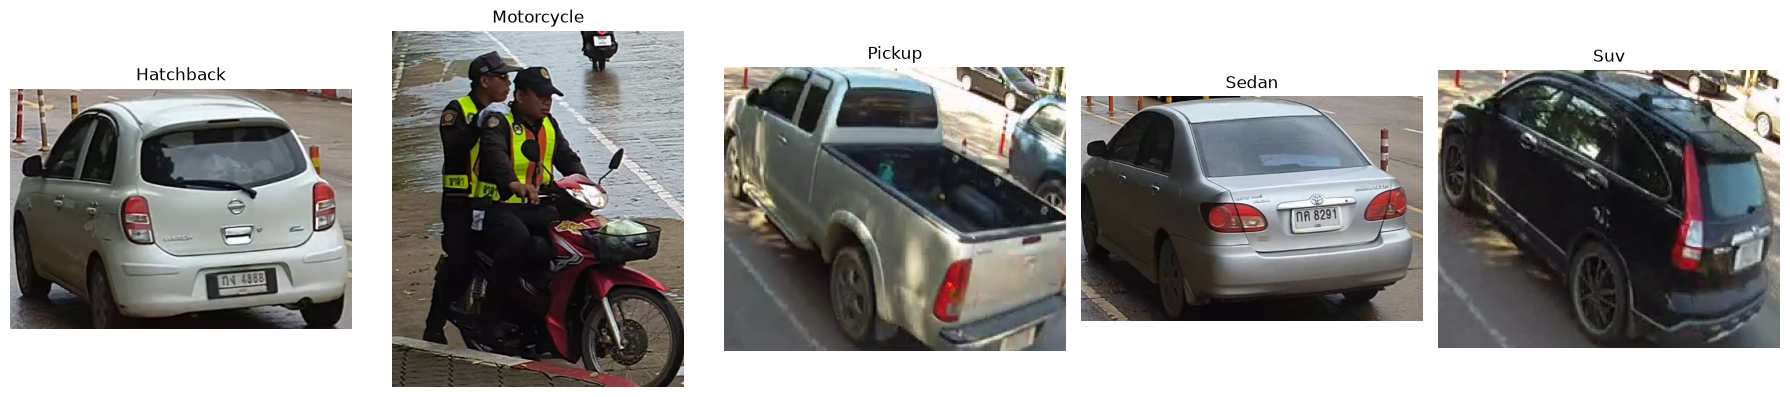

In [145]:
# Imports
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Loading the images
vehicle_types = [
    "hatchback",
    "motorcycle",
    "pickup",
    "sedan",
    "suv"
]

color_images = []
gray_images = []

for vehicle in vehicle_types:
    
    path = f"dataset/vehicle-type-detection/{vehicle}/PIC_30.jpg"
    
    color_image = cv2.imread(path)
    gray_image = cv2.cvtColor(color_image, cv2.COLOR_BGR2GRAY)
    
    color_images.append(color_image)
    gray_images.append(gray_image)

# Visualize the original images
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for ax, image, vehicle in zip(axes, color_images, vehicle_types):
    
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    ax.imshow(image_rgb)
    ax.set_title(vehicle.capitalize())
    ax.axis("off")

plt.tight_layout()
plt.show()

## Blob Detection Algorithm

The blob detection algorithm consists of thresholding, grouping connected pixels, merging nearby components, and calculating the center and radius of each detected blob.

The implementation is defined in the function below.

In [129]:
# Blob detection function

def detect_blobs(image, thresholds=[100, 150, 200], min_dist_between_blobs=30):
    
    # Thresholding
    binary_images = []
    
    for threshold in thresholds:
        
        _, binary = cv2.threshold(
            image,
            threshold,
            255,
            cv2.THRESH_BINARY
        )
        
        binary_images.append(binary)
    
    
    # Grouping connected pixels
    component_data = []
    
    for binary in binary_images:
        
        num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
            binary
        )
        
        # Remove the background
        stats = stats[1:]
        centroids = centroids[1:]
        
        component_data.append({
            "stats": stats,
            "centroids": centroids
        })
    
    
    # Merging nearby blobs
    blob_centers = []
    
    for data in component_data:
        for center in data["centroids"]:
            blob_centers.append(center)
    
    
    merged_centers = []
    
    for center in blob_centers:
        
        if len(merged_centers) == 0:
            merged_centers.append(center)
            continue
        
        distances = [
            np.linalg.norm(center - merged)
            for merged in merged_centers
        ]
        
        if min(distances) >= min_dist_between_blobs:
            merged_centers.append(center)
    
    
    # Calculate center, radius and area
    merged_blobs = []
    
    for center in merged_centers:
        
        # Find the closest original component
        closest_area = None
        closest_distance = float("inf")
        
        for data in component_data:
            
            for component_center, stats in zip(
                data["centroids"],
                data["stats"]
            ):
                
                distance = np.linalg.norm(
                    center - component_center
                )
                
                if distance < closest_distance:
                    closest_distance = distance
                    closest_area = stats[cv2.CC_STAT_AREA]
        
        radius = np.sqrt(closest_area / np.pi)
        
        merged_blobs.append({
            "center": center,
            "radius": radius,
            "area": closest_area
        })
    
    
    return merged_blobs

## Applying Blob Detection

The algorithm is applied to the images and the detected blobs are stored for further visualization and analysis.

In [134]:
# Apply blob detection
all_blobs = {}

for vehicle, image in zip(vehicle_types, gray_images):
    
    blobs = detect_blobs(
        image,
        thresholds=[100, 150, 200],
        min_dist_between_blobs=30
    )
    
    all_blobs[vehicle] = blobs
    
    print(
        f"{vehicle.capitalize()}: "
        f"{len(blobs)} blobs detected"
    )

Hatchback: 42 blobs detected
Motorcycle: 169 blobs detected
Pickup: 32 blobs detected
Sedan: 80 blobs detected
Suv: 31 blobs detected


## Visualization of Detected Blobs

The detected blobs are visualized on the original color images. Each detected blob is represented by a circle centered at the calculated blob position, with the circle radius corresponding to the estimated blob size.

The number of detected blobs is displayed together with the corresponding image.

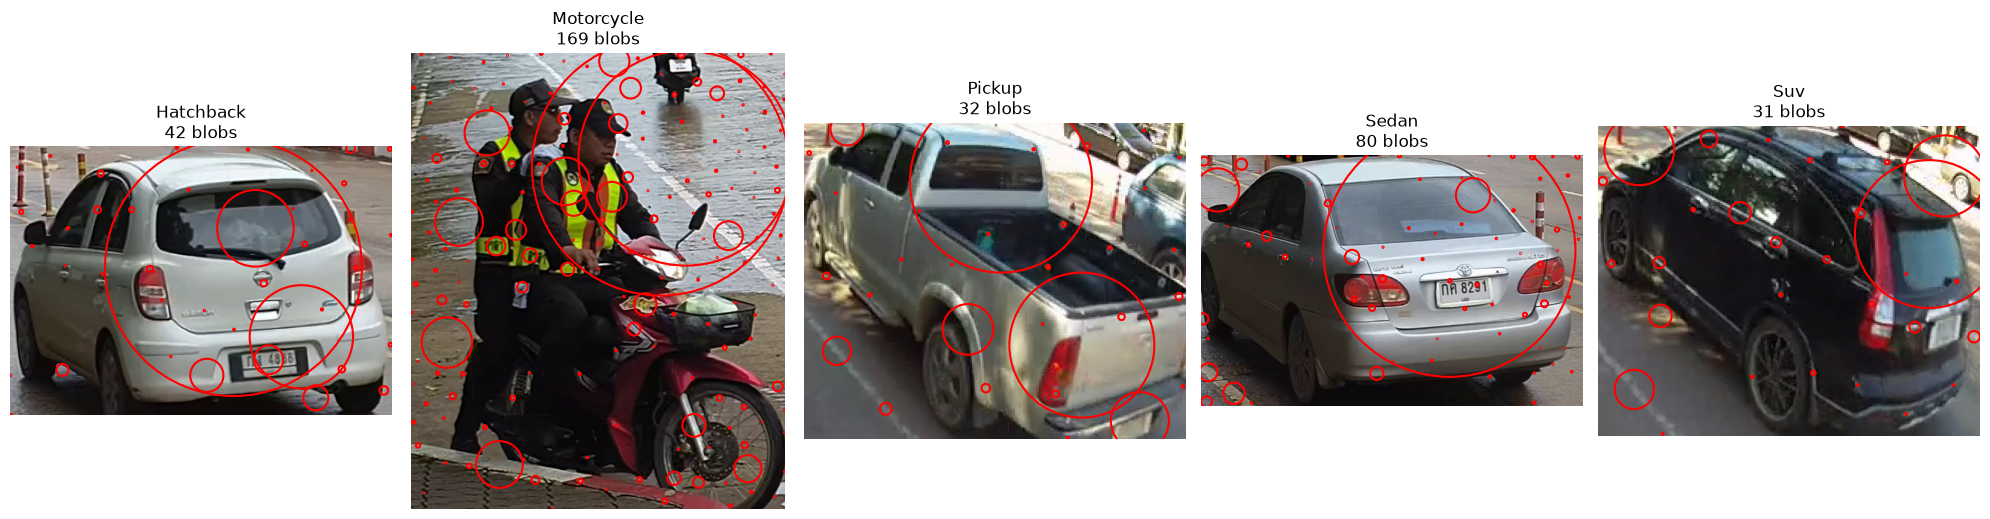

In [132]:
# Visualize the detected blobs
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for ax, vehicle, image in zip(axes, vehicle_types, color_images):
    
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    ax.imshow(image_rgb)
    
    blobs = all_blobs[vehicle]
    
    for blob in blobs:
        
        x, y = blob["center"]
        
        circle = plt.Circle(
            (x, y),
            blob["radius"],
            fill=False,
            edgecolor="red",
            linewidth=1.5
        )
        
        ax.add_patch(circle)
    
    ax.set_title(
        f"{vehicle.capitalize()}\n"
        f"{len(blobs)} blobs"
    )
    
    ax.axis("off")

plt.tight_layout()
plt.show()

## Blob Statistics

The number, position, radius, and area of the detected blobs are calculated for each image.

In [133]:
# Blob statistics
for vehicle in vehicle_types:
    
    blobs = all_blobs[vehicle]
    
    print(f"\n{vehicle.capitalize()}")
    print("-" * 40)
    
    print(f"Number of blobs: {len(blobs)}")
    
    for i, blob in enumerate(blobs, start=1):
        
        x, y = blob["center"]
        
        print(
            f"Blob {i}: "
            f"center=({x:.1f}, {y:.1f}), "
            f"radius={blob['radius']:.1f}px, "
            f"area={blob['area']:.0f}px²"
        )


Hatchback
----------------------------------------
Number of blobs: 42
Blob 1: center=(199.0, 107.7), radius=114.7px, area=41299px²
Blob 2: center=(303.6, 1.4), radius=4.0px, area=50px²
Blob 3: center=(80.5, 23.7), radius=2.7px, area=23px²
Blob 4: center=(159.0, 38.0), radius=1.0px, area=3px²
Blob 5: center=(77.8, 56.0), radius=3.0px, area=29px²
Blob 6: center=(108.1, 56.0), radius=2.2px, area=15px²
Blob 7: center=(218.6, 72.6), radius=34.2px, area=3666px²
Blob 8: center=(252.0, 55.0), radius=0.6px, area=1px²
Blob 9: center=(303.0, 65.0), radius=0.6px, area=1px²
Blob 10: center=(51.0, 72.5), radius=1.1px, area=4px²
Blob 11: center=(262.6, 86.5), radius=2.2px, area=15px²
Blob 12: center=(19.5, 88.5), radius=1.1px, area=4px²
Blob 13: center=(49.0, 106.0), radius=0.6px, area=1px²
Blob 14: center=(308.8, 107.6), radius=1.7px, area=9px²
Blob 15: center=(124.4, 108.8), radius=2.8px, area=24px²
Blob 16: center=(82.0, 113.5), radius=0.8px, area=2px²
Blob 17: center=(135.0, 137.0), radius=0.6p

## Effect of Parameters

Different parameter values are tested to investigate their effect on the detected blobs.

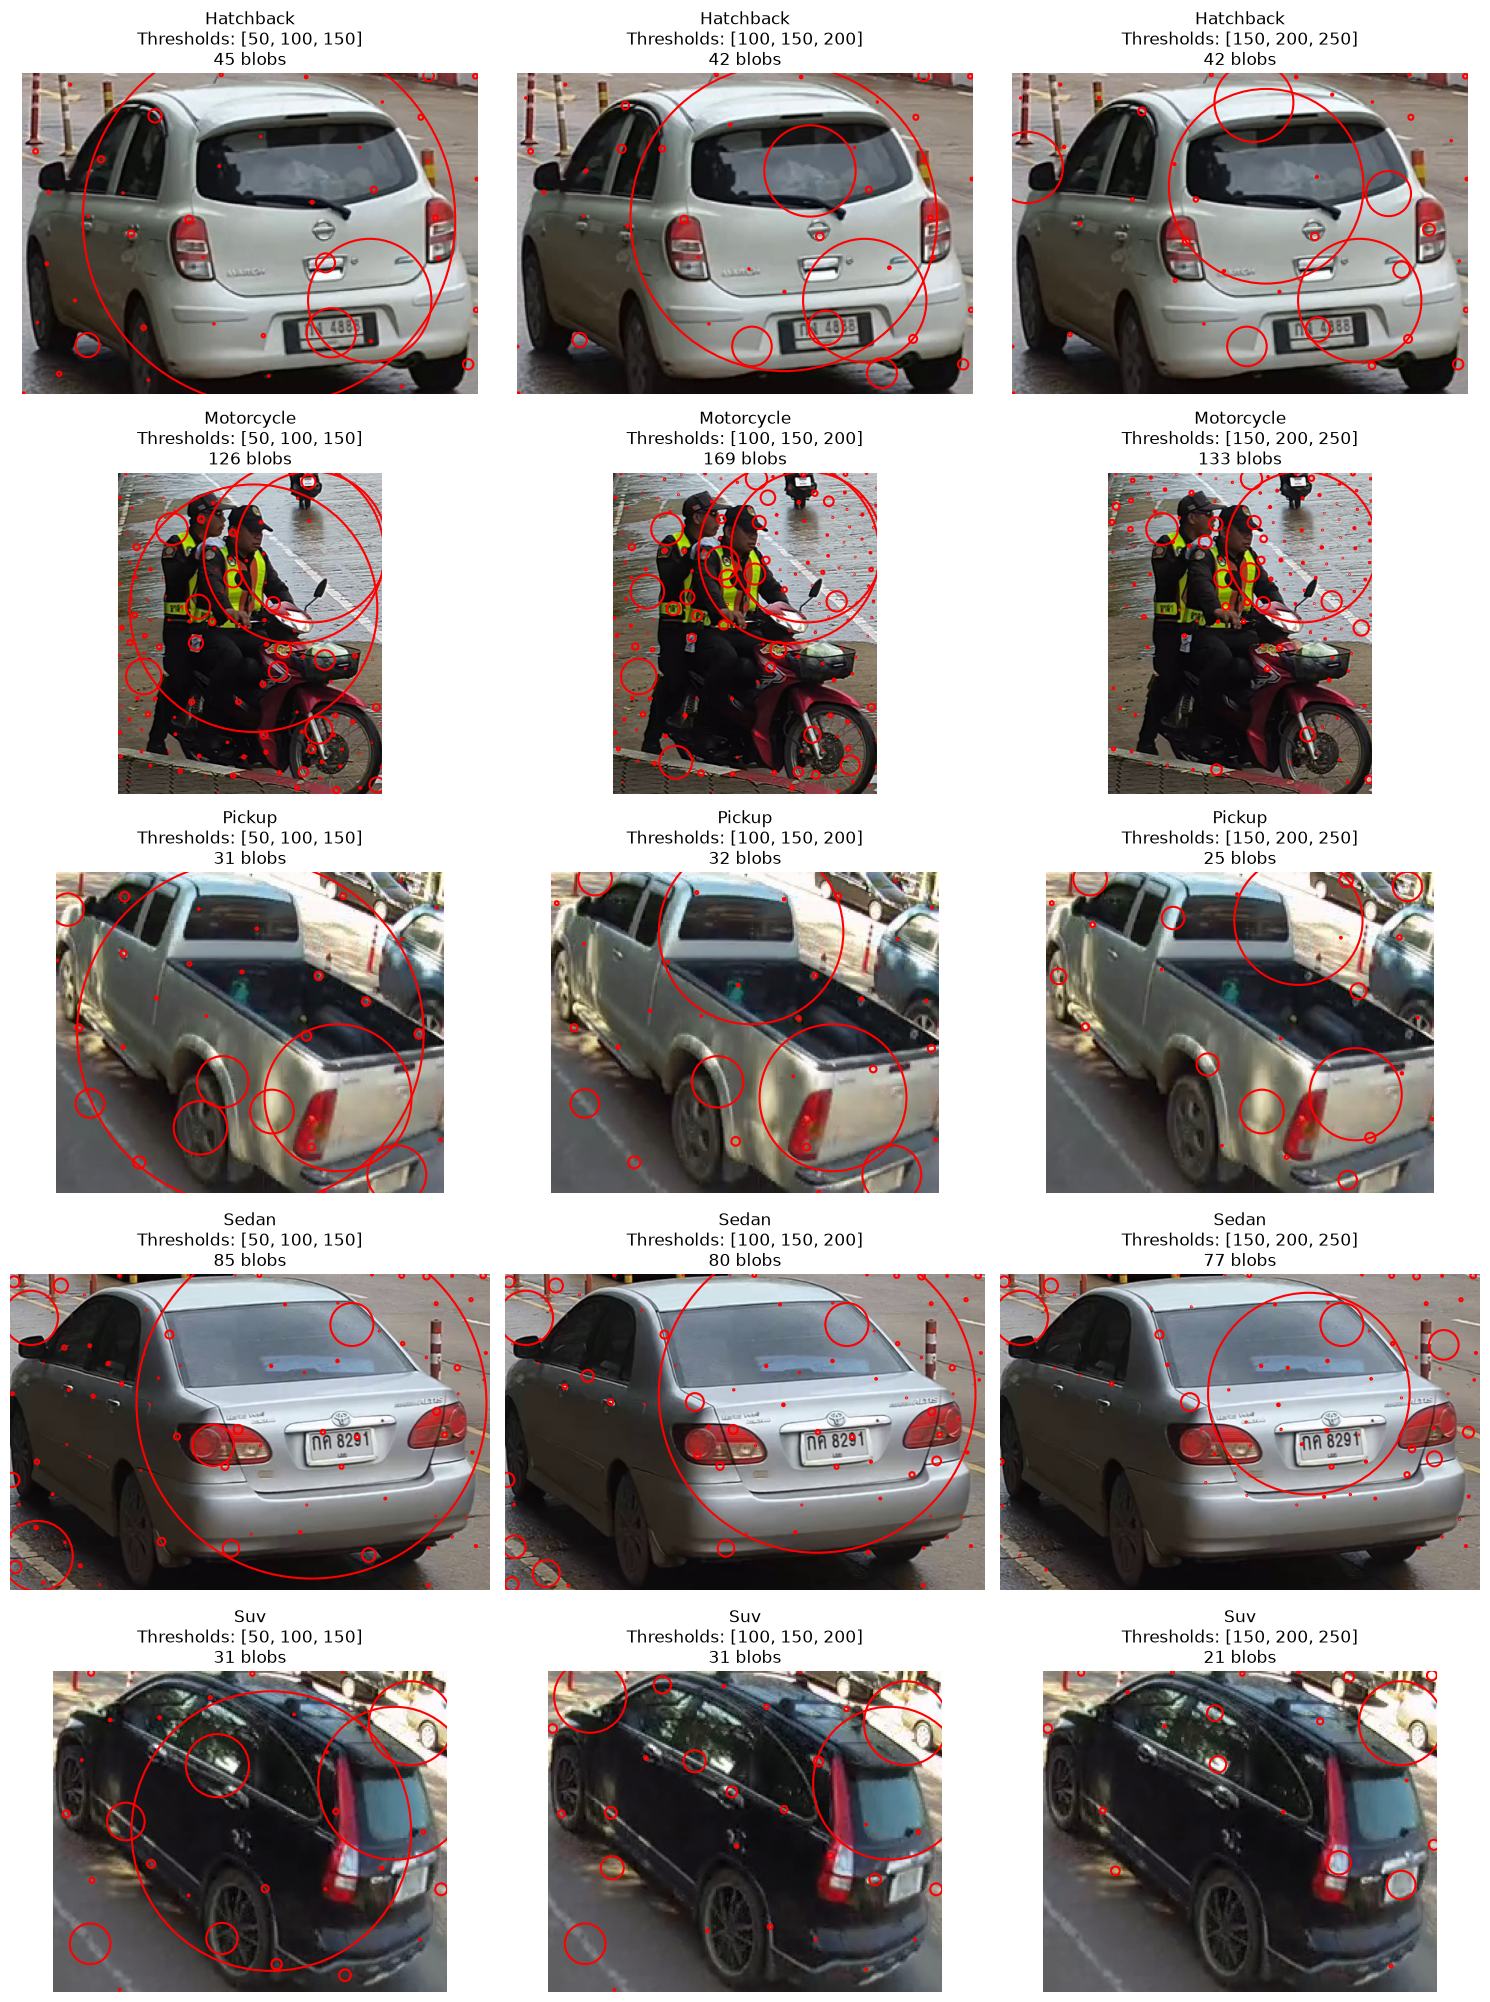

In [ ]:
# Test the effect of different threshold values
threshold_settings = [
    [50, 100, 150],
    [100, 150, 200],
    [150, 200, 250]
]

fig, axes = plt.subplots(
    len(vehicle_types),
    len(threshold_settings),
    figsize=(15, 20)
)

for i, (vehicle, image) in enumerate(
    zip(vehicle_types, gray_images)
):

    for j, thresholds in enumerate(threshold_settings):

        blobs = detect_blobs(
            image,
            thresholds=thresholds,
            min_dist_between_blobs=30
        )

        image_rgb = cv2.cvtColor(
            color_images[i],
            cv2.COLOR_BGR2RGB
        )

        axes[i, j].imshow(image_rgb)

        # Draw detected blobs
        for blob in blobs:

            x, y = blob["center"]

            circle = plt.Circle(
                (x, y),
                blob["radius"],
                fill=False,
                edgecolor="red",
                linewidth=1.5
            )

            axes[i, j].add_patch(circle)

        axes[i, j].set_title(
            f"{vehicle.capitalize()}\n"
            f"Thresholds: {thresholds}\n"
            f"{len(blobs)} blobs"
        )

        axes[i, j].axis("off")

plt.tight_layout()
plt.show()

In [141]:
# Compare the number of detected blobs for each threshold setting

for thresholds in threshold_settings:

    print(f"\nThresholds: {thresholds}")
    print("-" * 40)

    for vehicle, image in zip(vehicle_types, gray_images):

        blobs = detect_blobs(
            image,
            thresholds=thresholds,
            min_dist_between_blobs=30
        )

        print(f"{vehicle.capitalize():12s}: {len(blobs)} blobs")


Thresholds: [50, 100, 150]
----------------------------------------
Hatchback   : 45 blobs
Motorcycle  : 126 blobs
Pickup      : 31 blobs
Sedan       : 85 blobs
Suv         : 31 blobs

Thresholds: [100, 150, 200]
----------------------------------------
Hatchback   : 42 blobs
Motorcycle  : 169 blobs
Pickup      : 32 blobs
Sedan       : 80 blobs
Suv         : 31 blobs

Thresholds: [150, 200, 250]
----------------------------------------
Hatchback   : 42 blobs
Motorcycle  : 133 blobs
Pickup      : 25 blobs
Sedan       : 77 blobs
Suv         : 21 blobs


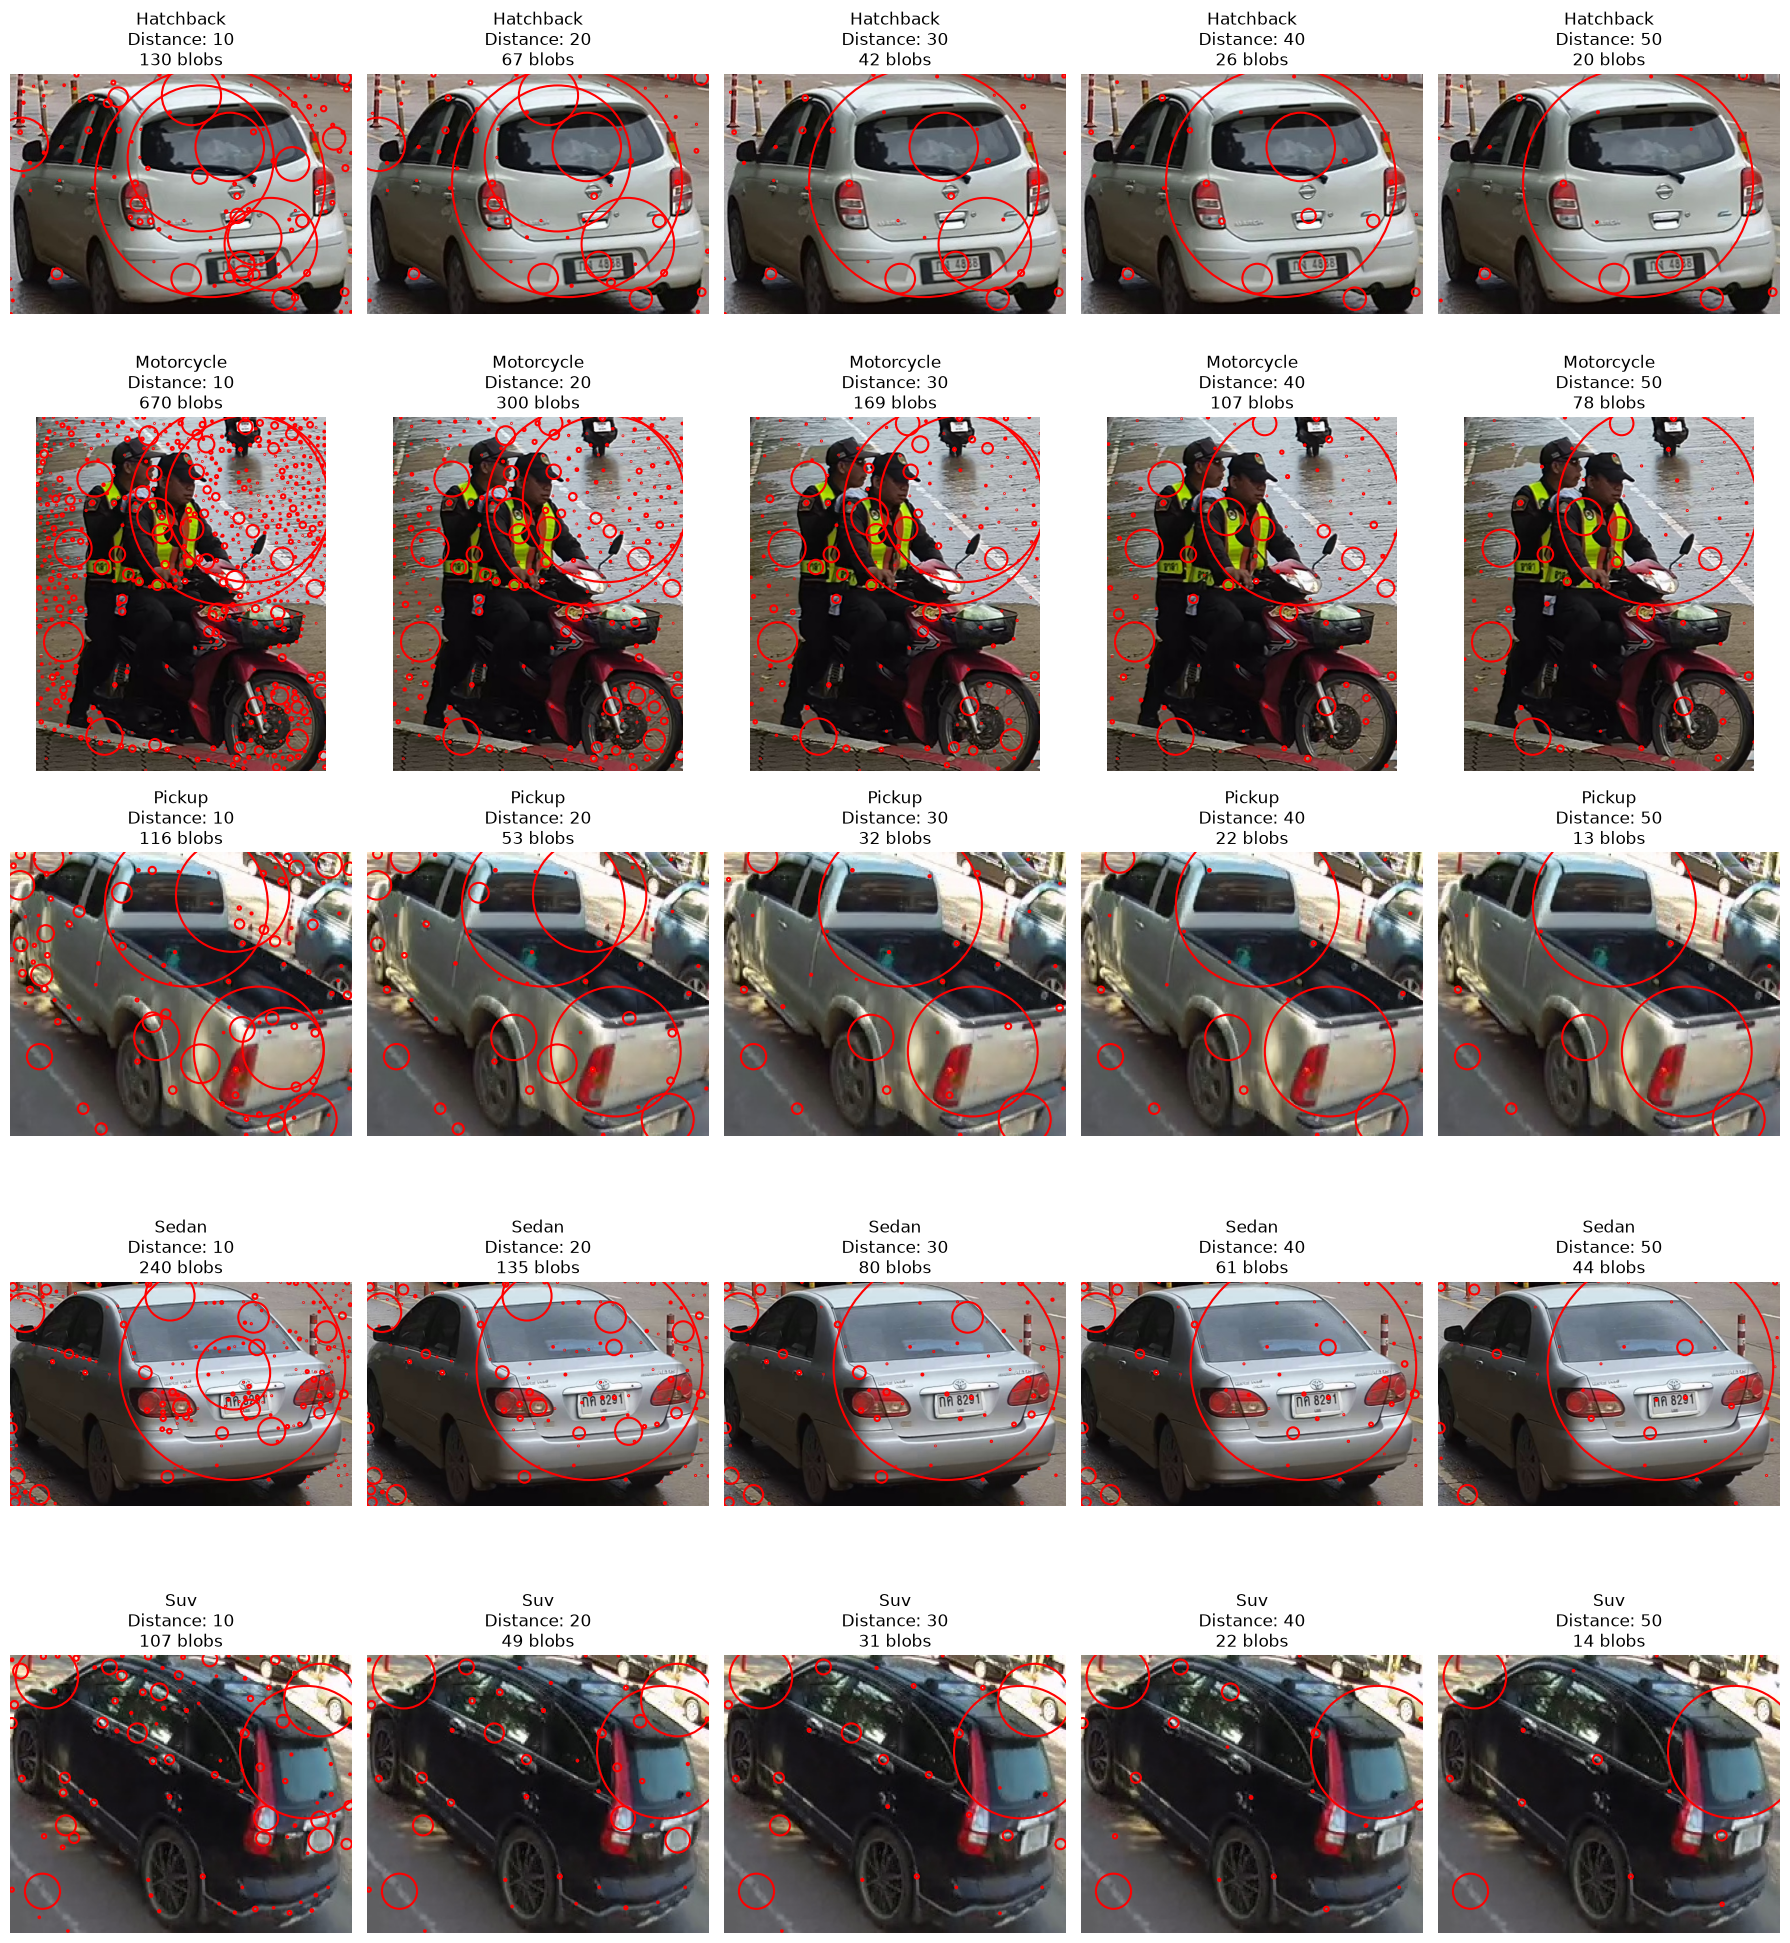

In [142]:
# Test the effect of minimum distance between blobs
distance_settings = [10, 20, 30, 40, 50]

fig, axes = plt.subplots(
    len(vehicle_types),
    len(distance_settings),
    figsize=(18, 20)
)

for i, (vehicle, image) in enumerate(
    zip(vehicle_types, gray_images)
):

    for j, distance in enumerate(distance_settings):

        blobs = detect_blobs(
            image,
            thresholds=[100, 150, 200],
            min_dist_between_blobs=distance
        )

        image_rgb = cv2.cvtColor(
            color_images[i],
            cv2.COLOR_BGR2RGB
        )

        axes[i, j].imshow(image_rgb)

        # Draw detected blobs
        for blob in blobs:

            x, y = blob["center"]

            circle = plt.Circle(
                (x, y),
                blob["radius"],
                fill=False,
                edgecolor="red",
                linewidth=1.5
            )

            axes[i, j].add_patch(circle)

        axes[i, j].set_title(
            f"{vehicle.capitalize()}\n"
            f"Distance: {distance}\n"
            f"{len(blobs)} blobs"
        )

        axes[i, j].axis("off")

plt.tight_layout()
plt.show()

In [143]:
# Compare the number of detected blobs for different distances
for distance in distance_settings:

    print(f"\nMinimum distance: {distance}")
    print("-" * 40)

    for vehicle, image in zip(vehicle_types, gray_images):

        blobs = detect_blobs(
            image,
            thresholds=[100, 150, 200],
            min_dist_between_blobs=distance
        )

        print(
            f"{vehicle.capitalize():12s}: "
            f"{len(blobs)} blobs"
        )


Minimum distance: 10
----------------------------------------
Hatchback   : 130 blobs
Motorcycle  : 670 blobs
Pickup      : 116 blobs
Sedan       : 240 blobs
Suv         : 107 blobs

Minimum distance: 20
----------------------------------------
Hatchback   : 67 blobs
Motorcycle  : 300 blobs
Pickup      : 53 blobs
Sedan       : 135 blobs
Suv         : 49 blobs

Minimum distance: 30
----------------------------------------
Hatchback   : 42 blobs
Motorcycle  : 169 blobs
Pickup      : 32 blobs
Sedan       : 80 blobs
Suv         : 31 blobs

Minimum distance: 40
----------------------------------------
Hatchback   : 26 blobs
Motorcycle  : 107 blobs
Pickup      : 22 blobs
Sedan       : 61 blobs
Suv         : 22 blobs

Minimum distance: 50
----------------------------------------
Hatchback   : 20 blobs
Motorcycle  : 78 blobs
Pickup      : 13 blobs
Sedan       : 44 blobs
Suv         : 14 blobs


In [146]:
# Create a table showing the effect of minimum distance
distance_results = []

for distance in distance_settings:

    for vehicle, image in zip(vehicle_types, gray_images):

        blobs = detect_blobs(
            image,
            thresholds=[100, 150, 200],
            min_dist_between_blobs=distance
        )

        distance_results.append({
            "Vehicle": vehicle.capitalize(),
            "Minimum distance": distance,
            "Number of blobs": len(blobs)
        })

distance_df = pd.DataFrame(distance_results)

distance_df.pivot(
    index="Vehicle",
    columns="Minimum distance",
    values="Number of blobs"
)

Minimum distance,10,20,30,40,50
Vehicle,,,,,
Hatchback,130,67,42,26,20
Motorcycle,670,300,169,107,78
Pickup,116,53,32,22,13
Sedan,240,135,80,61,44
Suv,107,49,31,22,14
